In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os
import glob as gb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from zipfile import ZipFile
import cv2

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"neazmulmowla","key":"31306d0d53ec1524dce6629147218271"}'}

In [3]:
!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {"username":"neazmulmowla","key":"31306d0d53ec1524dce6629147218271"}

import json

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

print('complete')

complete


In [4]:
!kaggle datasets download -d neazmulmowla/augmented-rop-dataset

Dataset URL: https://www.kaggle.com/datasets/neazmulmowla/augmented-rop-dataset
License(s): unknown
 98% 952M/967M [00:13<00:00, 106MB/s]
100% 967M/967M [00:13<00:00, 74.3MB/s]


In [5]:
from zipfile import ZipFile
file_name = '/content/augmented-rop-dataset.zip'

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('complete')

complete


In [6]:
from PIL import Image
import matplotlib.pyplot as plt
base_path = '/content/AUG-ROP'

In [7]:
# Load and process dataset
dataset_path = base_path
image_data = []
folders = {'Normal': 1, 'laser scars': 2, 'Stage1': 3, 'Stage2': 4, 'Stage3': 5}

for folder_name, label in folders.items():
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.exists(folder_path):
        image_files = os.listdir(folder_path)
        for image_file in image_files:
            image_data.append((os.path.join(folder_path, image_file), label))
    else:
        print(f"Folder {folder_path} not found.")

df = pd.DataFrame(image_data, columns=['image_path', 'label'])

In [8]:
# Check the number of images per class
class_counts = df.groupby('label').size().reset_index(name='count')

# Display the results
print("Number of images per class:")
print(class_counts)

Number of images per class:
   label  count
0      1    664
1      2    557
2      3    806
3      4    735
4      5    639


<ipython-input-9-b55625f3906a>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x='Class', y='ImageCount', palette="viridis")


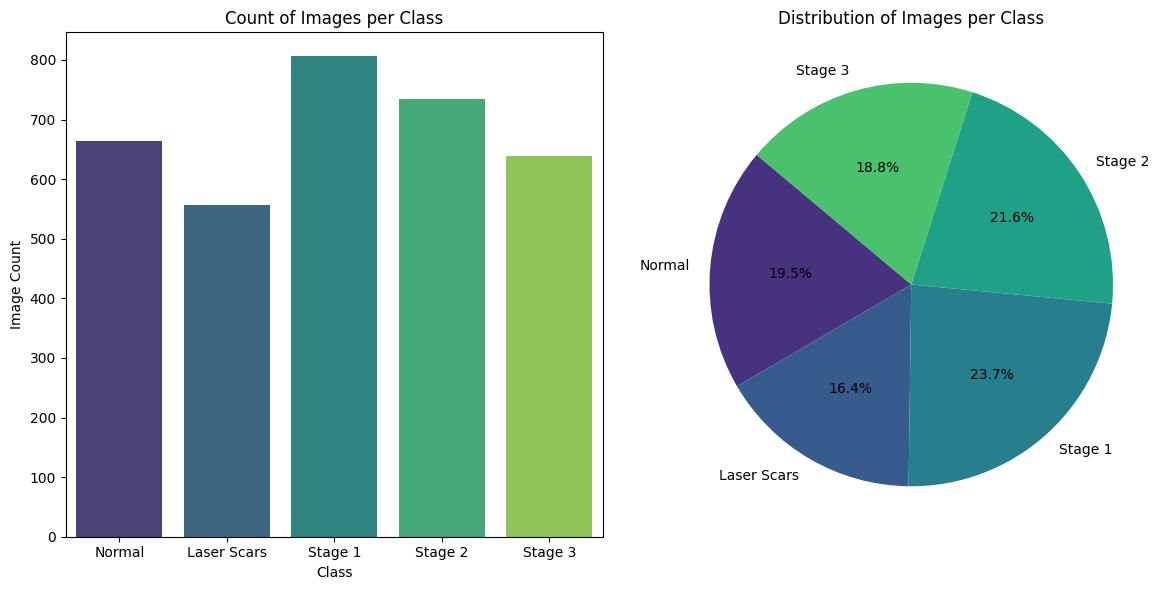

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of images per class
class_counts = df.groupby('label').size().reset_index(name='ImageCount')

# Map real class names to labels
class_names = {1: 'Normal', 2: 'Laser Scars', 3: 'Stage 1', 4: 'Stage 2', 5: 'Stage 3'}
class_counts['Class'] = class_counts['label'].map(class_names)

# Plot the bar chart and pie chart
plt.figure(figsize=(12, 6))

# Bar chart
plt.subplot(1, 2, 1)
sns.barplot(data=class_counts, x='Class', y='ImageCount', palette="viridis")
plt.title('Count of Images per Class')
plt.ylabel('Image Count')
plt.xlabel('Class')

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(class_counts['ImageCount'], labels=class_counts['Class'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis"))
plt.title('Distribution of Images per Class')

plt.tight_layout()
plt.show()

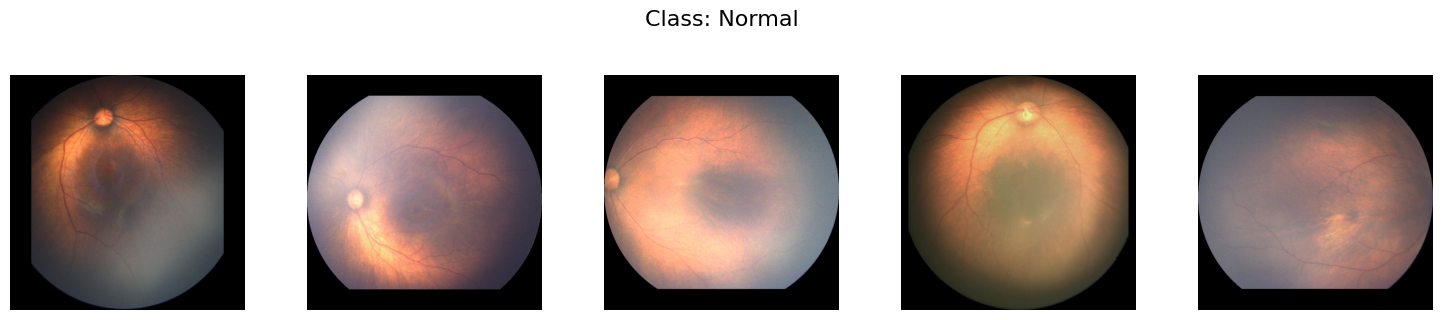

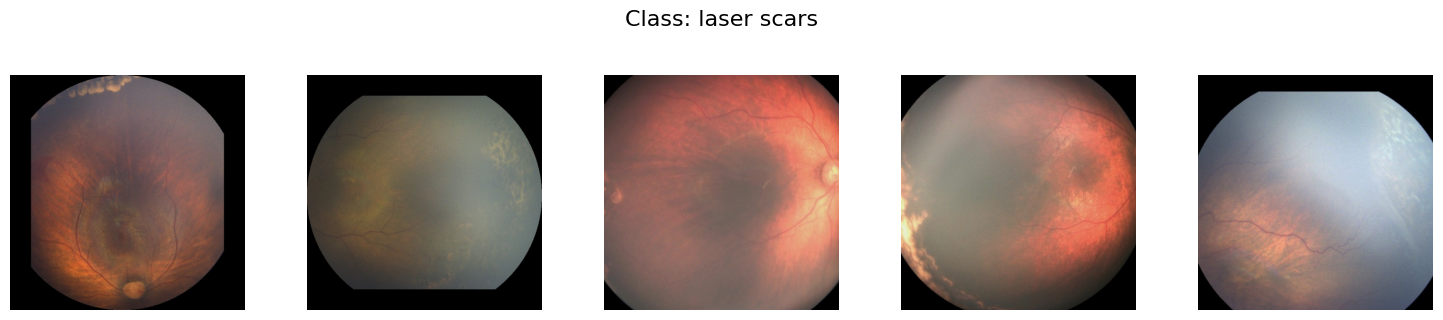

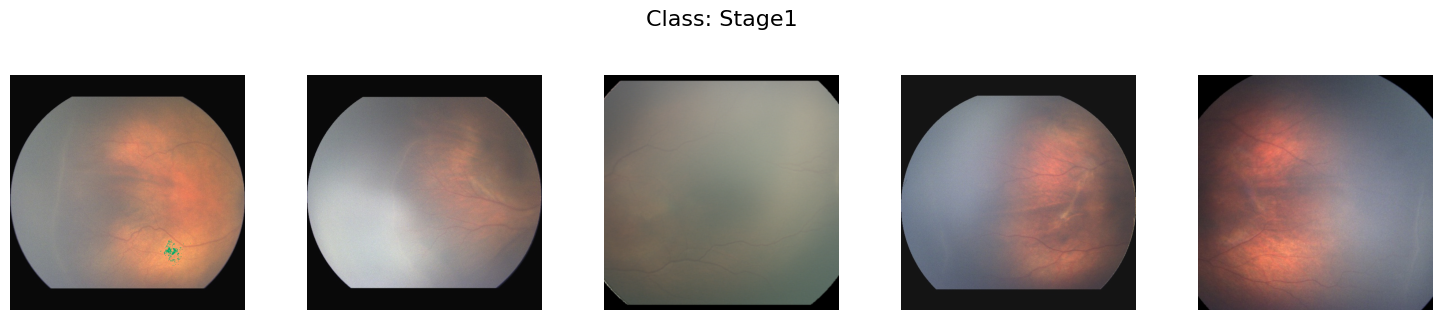

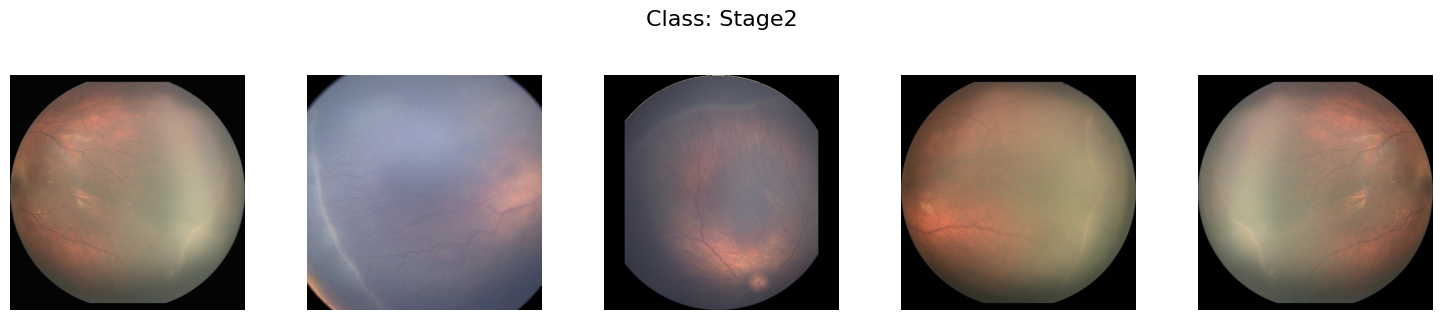

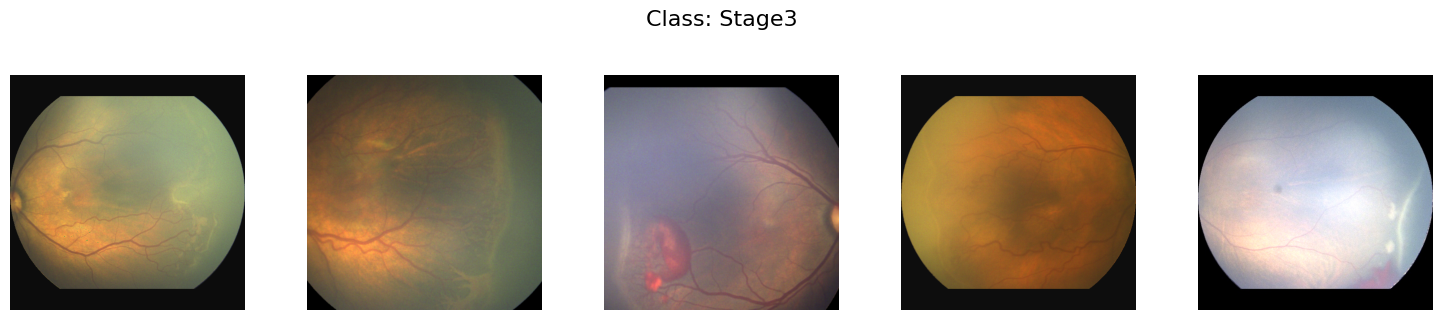

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define class names
classes = ['Normal', 'laser scars', 'Stage1', 'Stage2', 'Stage3']

# Base path of the dataset
base_path = dataset_path  # Replace with your actual dataset path

# Loop through each class and display 5 images
for class_name in classes:
    folder_path = os.path.join(base_path, class_name)
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    # Get the first 5 image files
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.png', '.jpg', '.jpeg'))][:5]

    # Plot images
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Class: {class_name}", fontsize=16, y=1.05)

    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        try:
            image = Image.open(image_path)
            plt.subplot(1, 5, i + 1)
            plt.imshow(image)
            plt.axis('off')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")

    plt.tight_layout()
    plt.show()


In [11]:
df.head()

,image_path,label
0,/content/AUG-ROP/Normal/Normal_34_aug_842.png,1
1,/content/AUG-ROP/Normal/Normal_60_aug_309.png,1
2,/content/AUG-ROP/Normal/Normal_236_aug_378.png,1
3,/content/AUG-ROP/Normal/Normal_207_aug_710.png,1
4,/content/AUG-ROP/Normal/Normal_47_aug_684.png,1


In [12]:
df.tail()

,image_path,label
3396,/content/AUG-ROP/Stage3/Stage_3_ROP_114_aug_51...,5
3397,/content/AUG-ROP/Stage3/Stage_3_ROP_30_aug_336...,5
3398,/content/AUG-ROP/Stage3/Stage_3_ROP_154_aug_85...,5
3399,/content/AUG-ROP/Stage3/Stage_3_ROP_211_aug_83...,5
3400,/content/AUG-ROP/Stage3/Stage_3_ROP_174_aug_42...,5


In [13]:
df.shape

(3401, 2)

In [14]:
df.columns

Index(['image_path', 'label'], dtype='object')

In [15]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Input  # Explicitly import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [16]:
from imblearn.over_sampling import RandomOverSampler

In [17]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['label'])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [18]:
df_resampled = pd.DataFrame(X_resampled, columns=['image_path'])
df_resampled['label'] = y_resampled

In [19]:
print("\nClass distribution after oversampling:")
print(df_resampled['label'].value_counts())


Class distribution after oversampling:
label
1    806
2    806
3    806
4    806
5    806
Name: count, dtype: int64


In [20]:
df_resampled

,image_path,label
0,/content/AUG-ROP/Normal/Normal_34_aug_842.png,1
1,/content/AUG-ROP/Normal/Normal_60_aug_309.png,1
2,/content/AUG-ROP/Normal/Normal_236_aug_378.png,1
3,/content/AUG-ROP/Normal/Normal_207_aug_710.png,1
4,/content/AUG-ROP/Normal/Normal_47_aug_684.png,1
...,...,...
4025,/content/AUG-ROP/Stage3/Stage_3_ROP_156_aug_65...,5
4026,/content/AUG-ROP/Stage3/Stage_3_ROP_40_aug_779...,5
4027,/content/AUG-ROP/Stage3/Stage_3_ROP_14_aug_626...,5
4028,/content/AUG-ROP/Stage3/Stage_3_ROP_44_aug_714...,5


In [21]:
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('check')

check


In [22]:
df_resampled['label'] = df_resampled['label'].astype(str)

In [23]:
train_df_new, temp_df_new = train_test_split(
    df_resampled,
    train_size=0.8,
    shuffle=True,
    random_state=42,
    stratify=df_resampled['label']
)

valid_df_new, test_df_new = train_test_split(
    temp_df_new,
    test_size=0.5,
    shuffle=True,
    random_state=42,
    stratify=temp_df_new['label']
)

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator(rescale=1./255)
ts_gen = ImageDataGenerator(rescale=1./255)

train_gen_new = tr_gen.flow_from_dataframe(
    train_df_new,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen_new = ts_gen.flow_from_dataframe(
    valid_df_new,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen_new = ts_gen.flow_from_dataframe(
    test_df_new,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

Found 3224 validated image filenames belonging to 5 classes.
Found 403 validated image filenames belonging to 5 classes.
Found 403 validated image filenames belonging to 5 classes.


In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [38]:
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("Using GPU")
else:
    print("Using CPU")

Using GPU


In [39]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Lightweight Xception Model
def create_lightweight_xception(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    base_model = Xception(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze all but the last 10 layers
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Global Average Pooling

    # Smaller Fully Connected Layers
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation='softmax')(x)  # Final Output Layer
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Model Parameters
input_shape = (224, 224, 3)  # Smaller input size for lightweight architecture
num_classes = 5  # Number of classes
lightweight_xception = create_lightweight_xception(input_shape, num_classes)

# Optimizer
optimizer = Adam(learning_rate=0.0001)

# Compile the model
lightweight_xception.compile(optimizer=optimizer,
                             loss='sparse_categorical_crossentropy',
                             metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)

# Model Summary
lightweight_xception.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 111, 111, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 111, 111, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 111, 111, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 109, 109, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 109, 109, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 109, 109, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 109, 109, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 109, 109, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 109, 109, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 55, 55, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 55, 55, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 20,994,861 (80.09 MB)

 Trainable params: 5,629,701 (21.48 MB)

 Non-trainable params: 15,365,160 (58.61 MB)

In [40]:
history = lightweight_xception.fit(
    train_gen_new,
    validation_data=valid_gen_new,
    epochs=100,
    callbacks=[lr_reducer , early_stopping],
    verbose=1
)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 73s 514ms/step - accuracy: 0.3830 - loss: 1.4462 - val_accuracy: 0.4516 - val_loss: 1.3951 - learning_rate: 1.0000e-04
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 29s 269ms/step - accuracy: 0.6886 - loss: 0.8237 - val_accuracy: 0.5707 - val_loss: 1.3088 - learning_rate: 1.0000e-04
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 42s 272ms/step - accuracy: 0.8074 - loss: 0.5462 - val_accuracy: 0.6501 - val_loss: 1.1827 - learning_rate: 1.0000e-04
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 28s 267ms/step - accuracy: 0.8755 - loss: 0.3809 - val_accuracy: 0.7891 - val_loss: 0.5240 - learning_rate: 1.0000e-04
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 44s 294ms/step - accuracy: 0.9204 - loss: 0.2724 - val_accuracy: 0.7965 - val_loss: 0.4780 - learning_rate: 1.0000e-04
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 38s 268ms/step - accuracy: 0.9250 - loss: 0.2318 - val_accuracy: 0.8337 - val_loss: 0.4330 - learning_rate: 1.0000e-04
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━

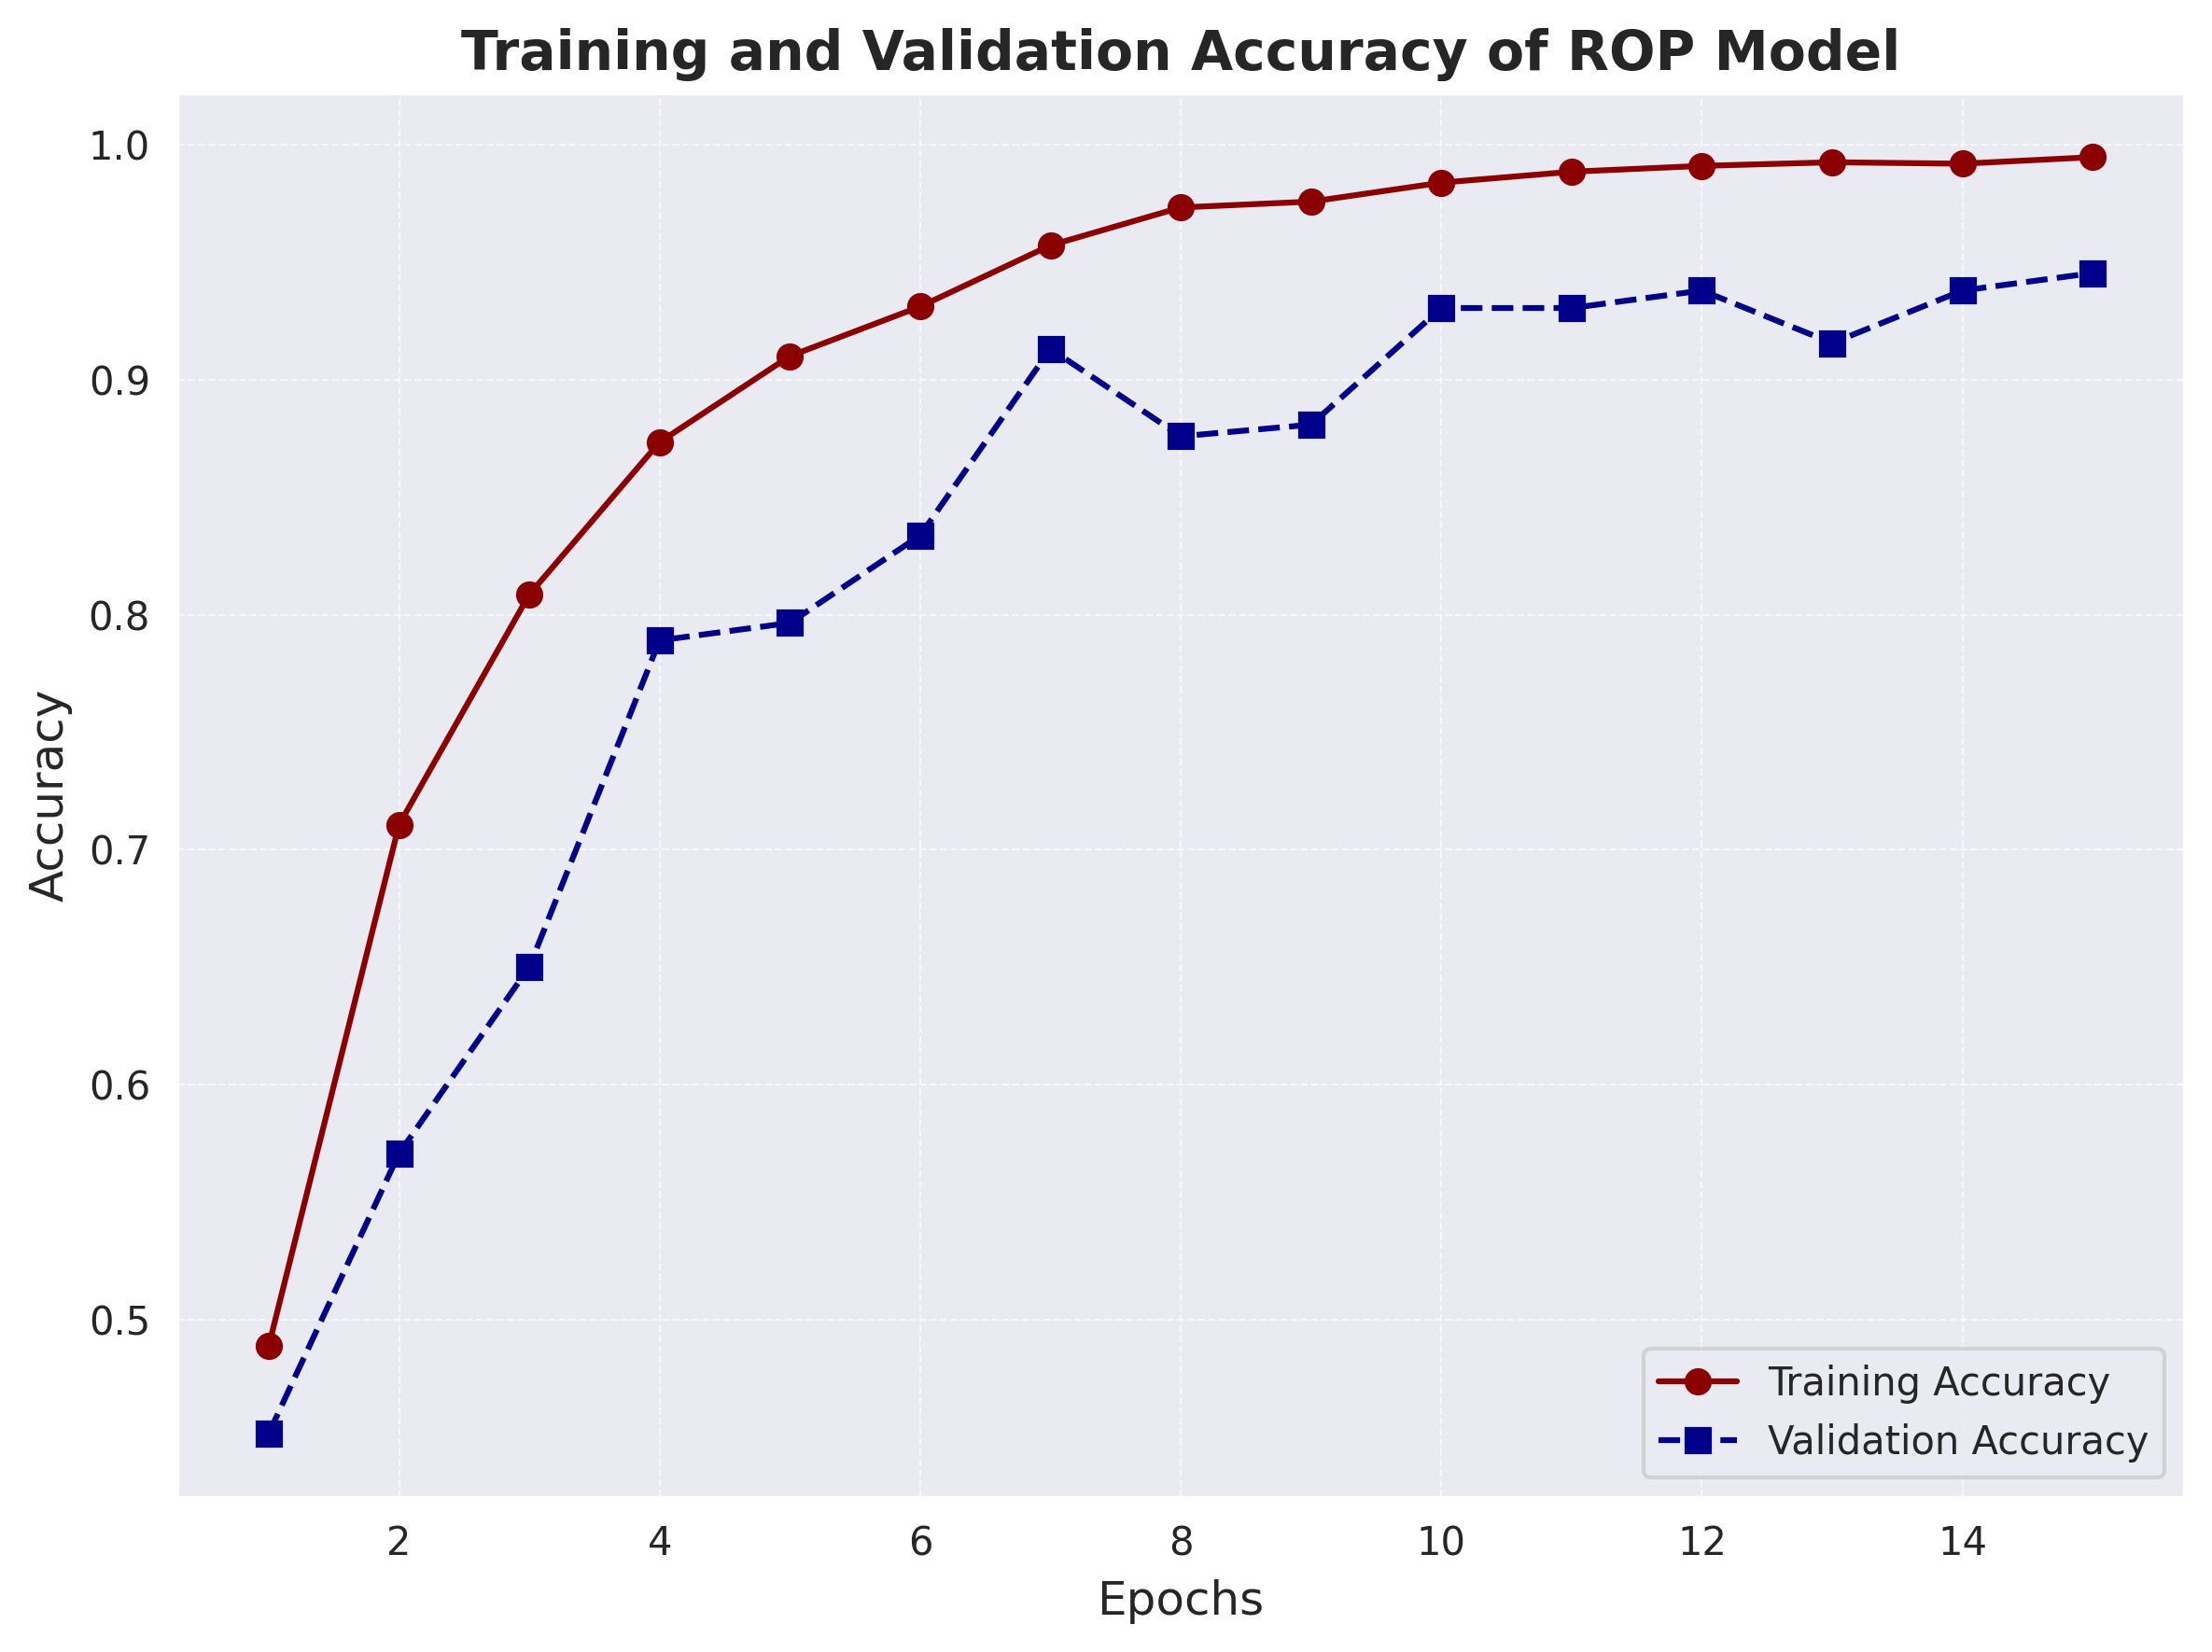

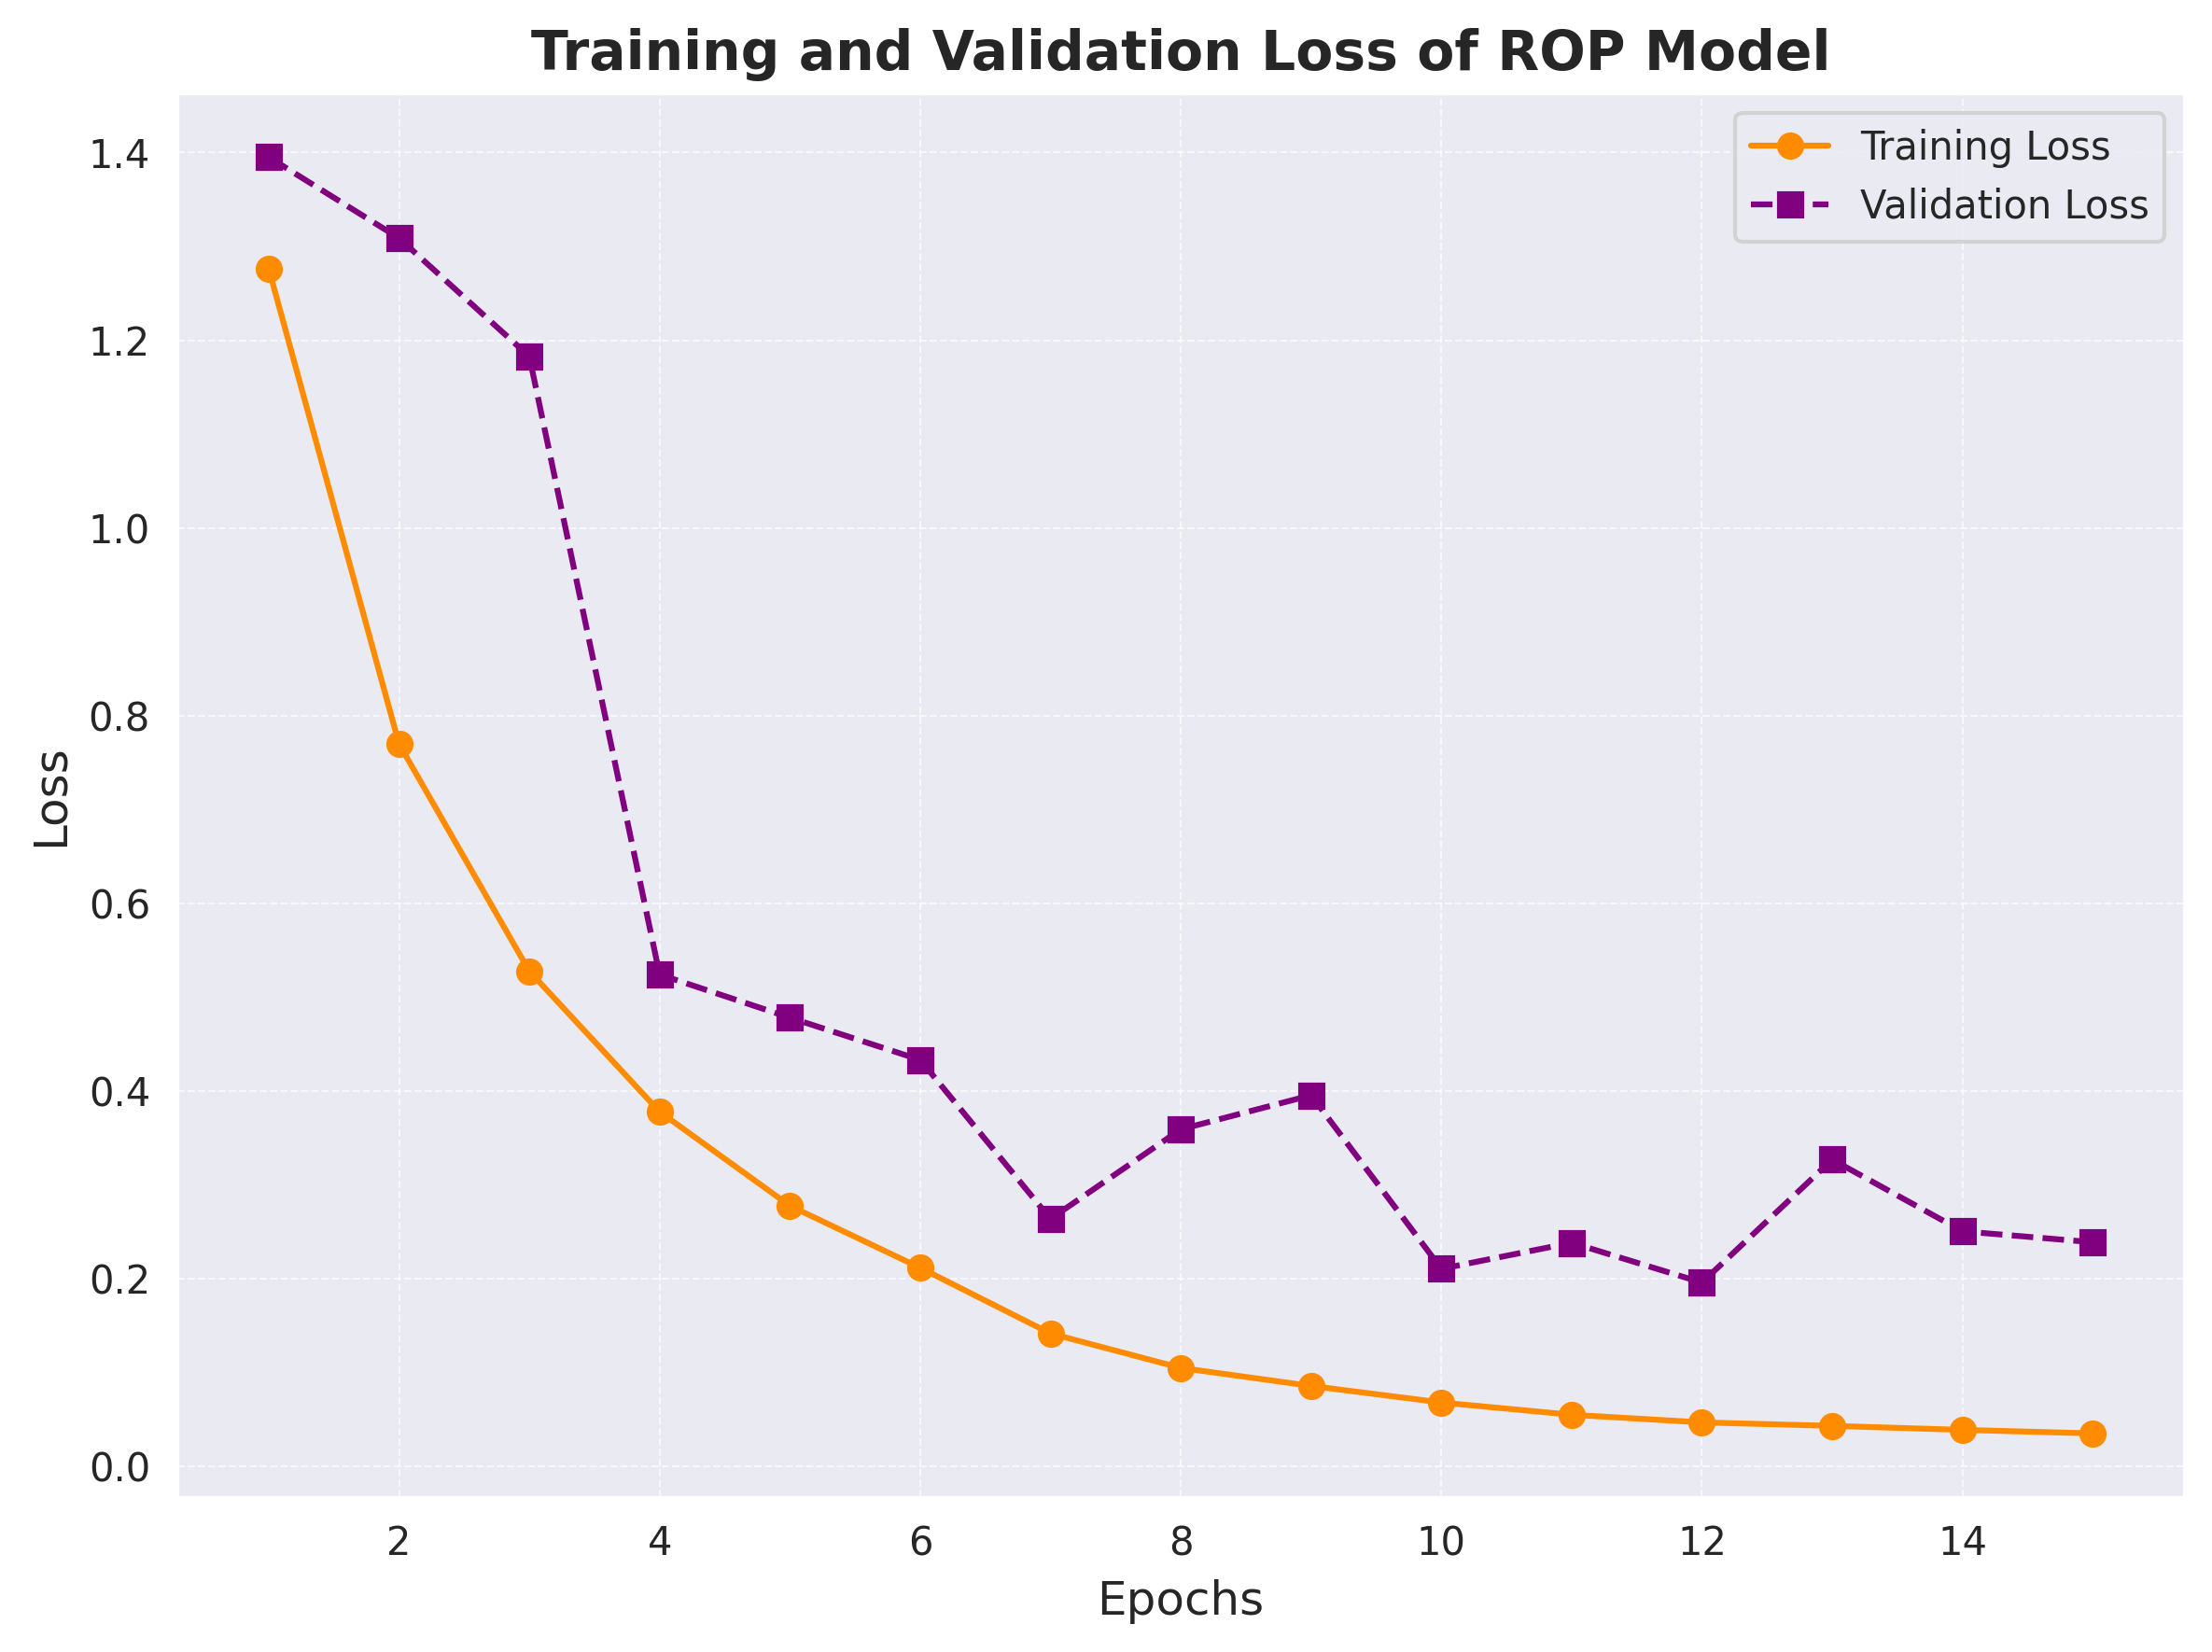

In [41]:
import matplotlib.pyplot as plt
accuracy = history.history['accuracy']
valid_accuracy = history.history['val_accuracy']
loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(accuracy) + 1)
# Plot accuracy
plt.figure(figsize=(8, 6), dpi=300)
plt.plot(epochs, accuracy, color='darkred', linestyle='-', marker='o', label='Training Accuracy')
plt.plot(epochs, valid_accuracy, color='darkblue', linestyle='--', marker='s', label='Validation Accuracy')
plt.title('Training and Validation Accuracy of ROP Model', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='lower right')
plt.grid(visible=True, linestyle='--', linewidth=0.5, alpha=0.7)  # Add a faint grid
plt.tight_layout()  # Adjust layout for saving
plt.savefig('enhanced_accuracy_plot.png', bbox_inches='tight', dpi=300)
plt.show()

# Plot loss
plt.figure(figsize=(8, 6), dpi=300)
plt.plot(epochs, loss, color='darkorange', linestyle='-', marker='o', label='Training Loss')
plt.plot(epochs, valid_loss, color='purple', linestyle='--', marker='s', label='Validation Loss')
plt.title('Training and Validation Loss of ROP Model', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10, loc='upper right')
plt.grid(visible=True, linestyle='--', linewidth=0.5, alpha=0.7)  # Add a faint grid
plt.tight_layout()  # Adjust layout for saving
plt.savefig('enhanced_loss_plot.png', bbox_inches='tight', dpi=300)
plt.show()


In [43]:
test_labels = test_gen_new.classes
predictions = lightweight_xception.predict(test_gen_new)
predicted_classes = np.argmax(predictions, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 424ms/step


In [45]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_gen_new.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           1       0.98      1.00      0.99        81
           2       0.99      0.99      0.99        80
           3       0.97      0.89      0.93        81
           4       0.90      0.90      0.90        81
           5       0.89      0.95      0.92        80

    accuracy                           0.95       403
   macro avg       0.95      0.95      0.95       403
weighted avg       0.95      0.95      0.95       403



In [46]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)

In [47]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
test_accuracy = accuracy_score(test_labels, predicted_classes)

# Print the accuracy
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 94.54%


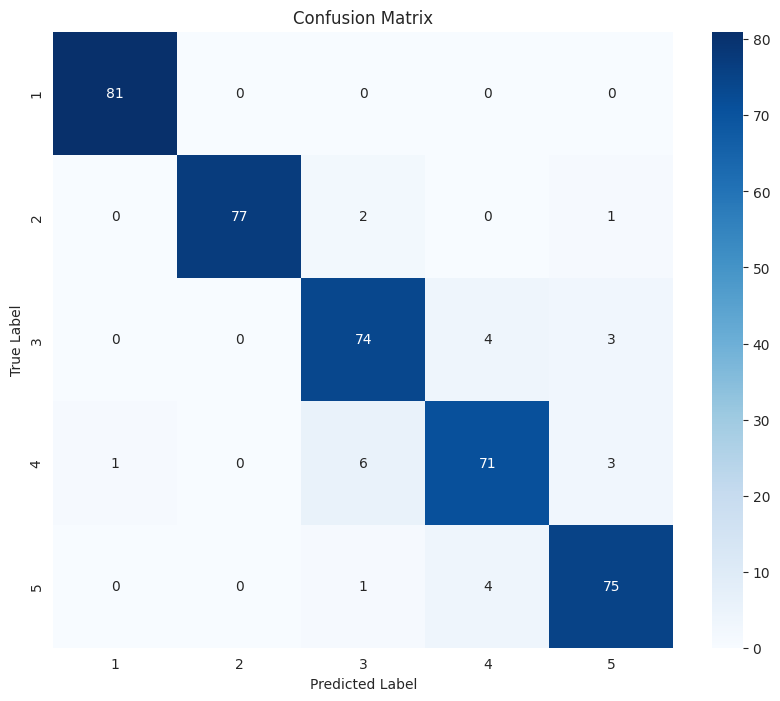

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_gen_new.class_indices.keys()), yticklabels=list(test_gen_new.class_indices.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step


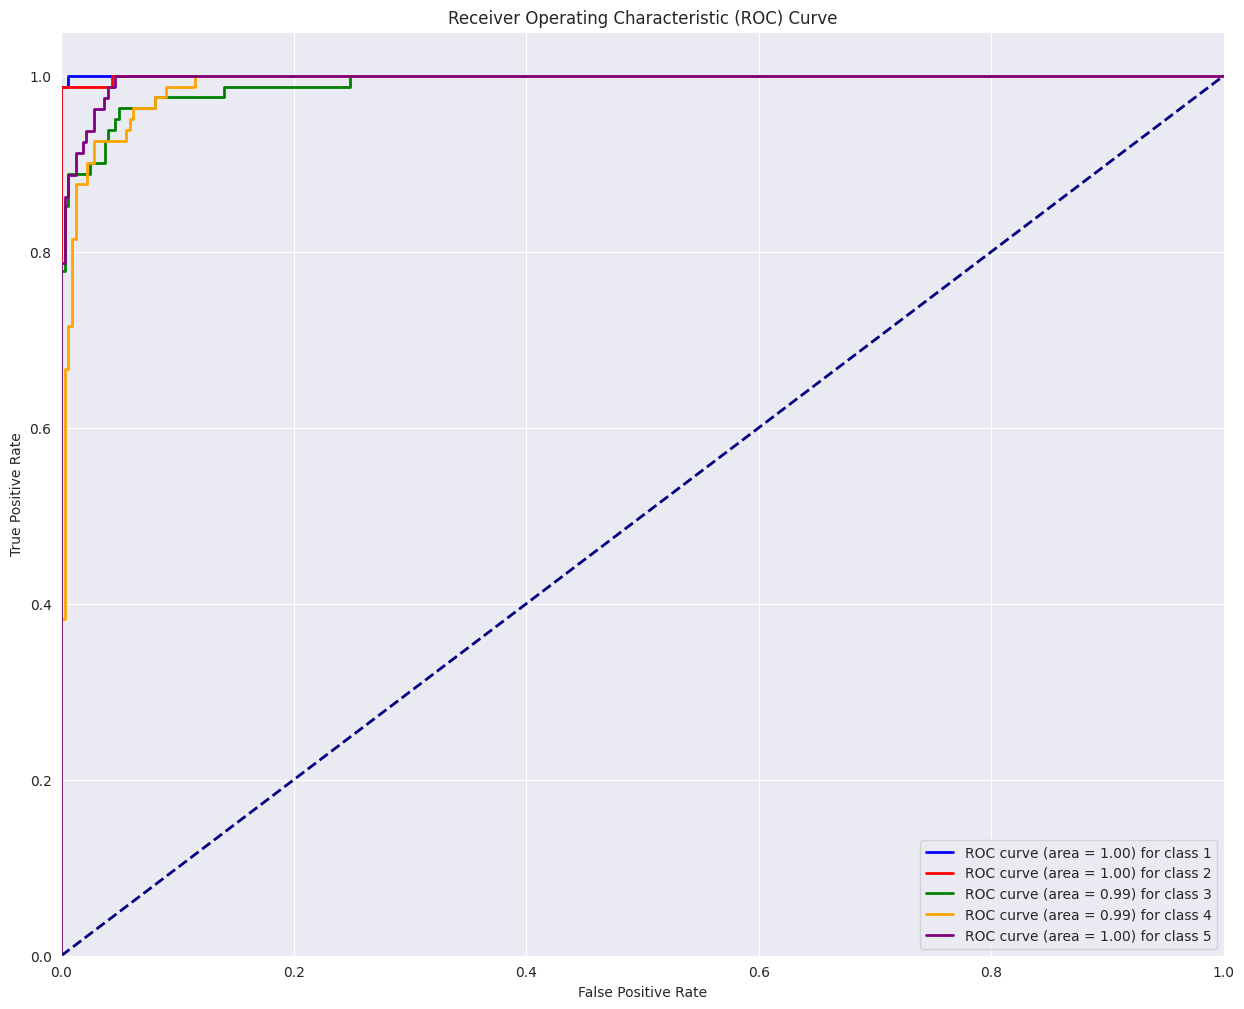

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Replace predict_generator with predict
Y_score = lightweight_xception.predict(test_gen_new)

# Get class names from the test_data generator
class_names = list(test_gen_new.class_indices.keys())

# Define colors for each class
colors = ['blue', 'red', 'green', 'orange', 'purple']  # Adjust colors as needed

# Binarize the true labels (one-hot encoding)
y_true = label_binarize(test_gen_new.classes, classes=list(range(len(class_names))))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_names)):  # num_classes is the number of classes in your problem
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], Y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(15, 12))
lw = 2
for i in range(len(class_names)):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=lw,
             label='ROC curve (area = {0:0.2f}) for class {1}'.format(roc_auc[i], class_names[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()